In [209]:
import os, sys, time
from scipy import stats
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import pandas as pd
import numpy as np
%matplotlib inline

from IPython.display import display, HTML

if (sys.version_info < (3, 0)):
    HTML('''<script>
    code_show=true; 
    function code_toggle() {
     if (code_show){
     $('div.input').hide();
     } else {
     $('div.input').show();
     }
     code_show = !code_show
    } 
    $( document ).ready(code_toggle);
    </script>
    <form action="javascript:code_toggle()"><input type="submit" value="Click here to toggle on/off the raw code."></form>''')


In [210]:
# Create timestamp to show when this summary was run
print('Summary run: ' + time.strftime("%a, %d %b %Y %H:%M"))

Summary run: Tue, 18 Nov 2025 10:55


In [211]:
relative_path = '../../../../outputs'
pd.options.display.float_format = '{:0,.0f}'.format
format_percent = "{:,.2%}".format

# Traffic Counts
----
### Daily | By Facility Type

In [212]:
df = pd.read_csv(os.path.join(relative_path,'validation','daily_volume.csv'))
df[['modeled','observed']] = df[['modeled','observed']].astype('float')

In [213]:
_df = df.groupby('@facilitytype').sum()[['observed','modeled']]
_df.loc['Total',:] = _df.sum().values
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df.reindex(['Freeway', 'Arterial', 'Collector', 'Ramp', 'Total'])

,observed,modeled,diff,percent_diff
@facilitytype,,,,
Freeway,"28,161,110","25,560,669","-2,600,441",-9.23%
Arterial,"16,572,087","12,917,664","-3,654,423",-22.05%
Collector,"6,456,804","1,998,873","-4,457,931",-69.04%
Ramp,"3,914,531","714,770","-3,199,761",-81.74%
Total,"55,104,532","41,191,976","-13,912,556",-25.25%


#### Daily | By Facility Type - Pierce County

In [214]:
df1 = df[df['county'] == 'Pierce']

In [215]:
_df = df1.groupby('@facilitytype').sum()[['observed','modeled']]
_df.loc['Total',:] = _df.sum().values
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df.reindex(['Freeway', 'Arterial', 'Collector', 'Ramp', 'Total'])

,observed,modeled,diff,percent_diff
@facilitytype,,,,
Freeway,"3,906,705","4,315,272","408,567",10.46%
Arterial,"4,570,332","4,370,785","-199,547",-4.37%
Collector,"1,774,475","726,119","-1,048,356",-59.08%
Ramp,"1,255,226","406,548","-848,678",-67.61%
Total,"11,506,738","9,818,724","-1,688,014",-14.67%


#### Daily | By Facility Type - Other Counties

In [216]:
df2 = df[df['county'] != 'Pierce']

In [217]:
_df = df2.groupby('@facilitytype').sum()[['observed','modeled']]
_df.loc['Total',:] = _df.sum().values
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df.reindex(['Freeway', 'Arterial', 'Collector', 'Ramp', 'Total'])

,observed,modeled,diff,percent_diff
@facilitytype,,,,
Freeway,"24,254,405","21,245,397","-3,009,008",-12.41%
Arterial,"12,001,755","8,546,879","-3,454,876",-28.79%
Collector,"4,682,329","1,272,754","-3,409,575",-72.82%
Ramp,"2,659,305","308,222","-2,351,083",-88.41%
Total,"43,597,794","31,373,252","-12,224,542",-28.04%


----
### Daily | By County

In [218]:
df = pd.read_csv(os.path.join(relative_path,'validation','daily_volume_county_facility.csv'))
df[['modeled','observed']] = df[['modeled','observed']].astype('float')

_df = df.groupby('county').sum()[['observed','modeled']]
_df.loc['Total',:] = _df.sum().values
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df

,observed,modeled,diff,percent_diff
county,,,,
King,"33,101,720","22,829,676","-10,272,044",-31.03%
Kitsap,"85,558","320,588","235,030",274.70%
Pierce,"11,506,738","9,818,724","-1,688,014",-14.67%
Snohomish,"10,410,516","8,222,988","-2,187,528",-21.01%
Total,"55,104,532","41,191,976","-13,912,556",-25.25%


----
### Daily | Scatterplots 

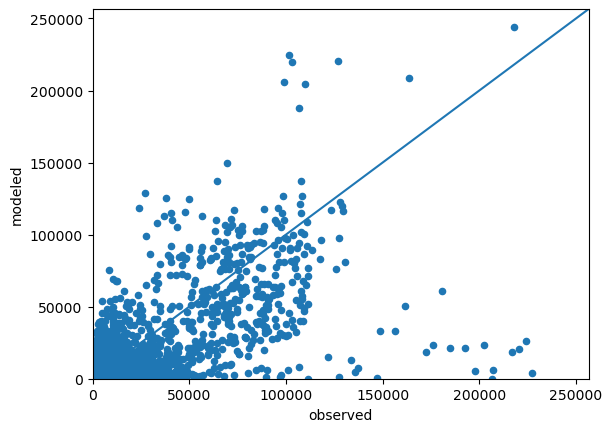

In [219]:
df = pd.read_csv(os.path.join(relative_path,'validation','daily_volume.csv'))
ax = df.plot(kind='scatter', x='observed', y='modeled')
lim = df[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)

In [220]:
slope, intercept, r_value, p_value, std_err = stats.linregress(df['observed'],df['modeled'])
print('r^2: ' + str(r_value))

r^2: 0.5979929997544896


---
By County

King r^2: 0.5685696629082867
Kitsap r^2: 0.5191340900121506
Pierce r^2: 0.6537511288485641
Snohomish r^2: 0.6554480021534871


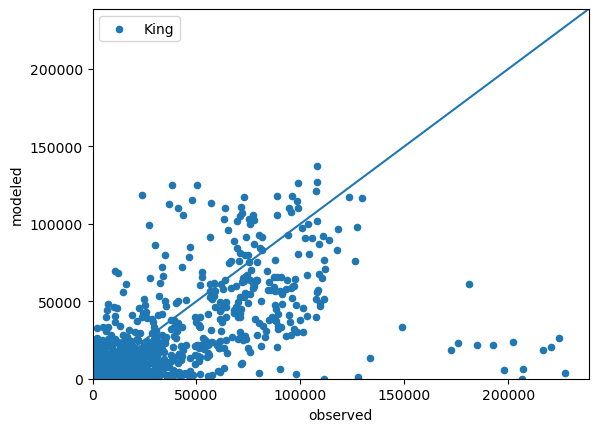

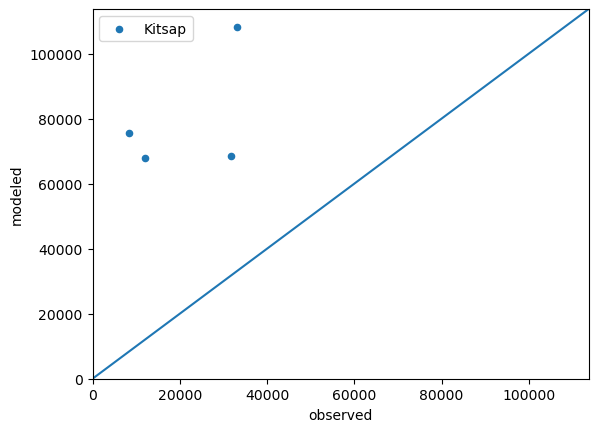

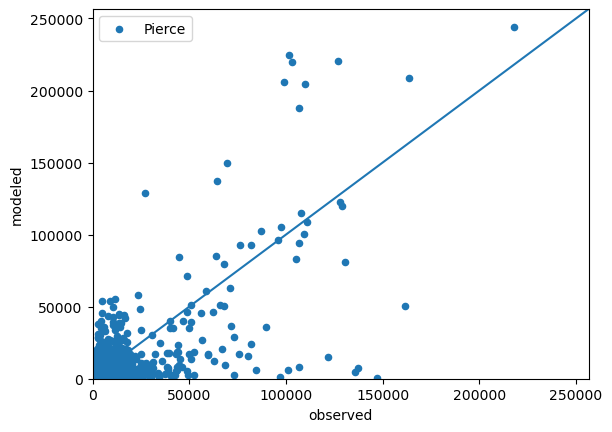

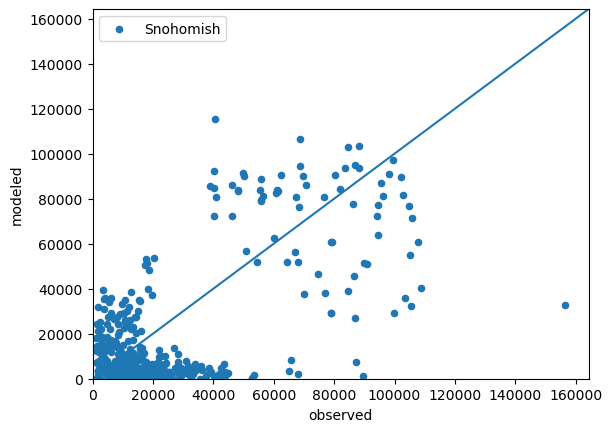

In [221]:
for county in np.unique(df[~df.county.isna()]['county']):
    _df = df[df['county'] == county]
    ax = _df.plot(kind='scatter', x='observed', y='modeled', label=county)
    lim = _df[['observed','modeled']].max().max()*1.05
    ax.set_ylim(0,lim)
    ax.set_xlim(0,lim)
    slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed'],_df['modeled'])
    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x)
    print(str(county) + ' r^2: ' + str(r_value))

---
By Facility Type

r^2 Freeway: 0.3495923149910937
r^2 Arterial: 0.07916972367609743


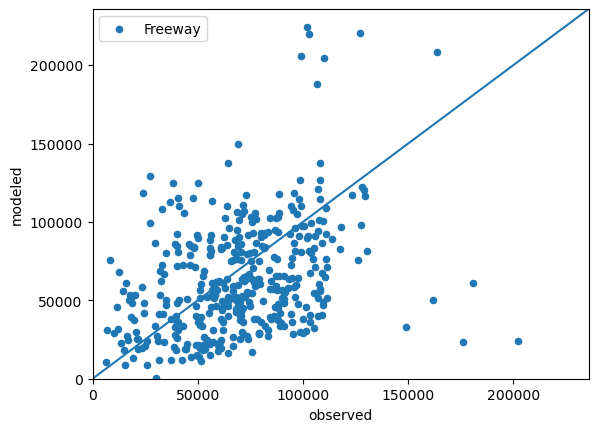

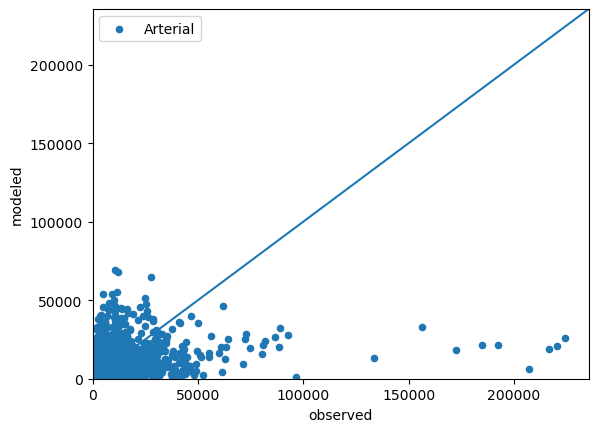

In [222]:
for factype in ['Freeway','Arterial']:
    _df = df[df['@facilitytype'] == factype]
    ax = _df.plot(kind='scatter', x='observed', y='modeled', label=factype)
    lim = _df[['observed','modeled']].max().max()*1.05
    ax.set_ylim(0,lim)
    ax.set_xlim(0,lim)
    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x)
    slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed'],_df['modeled'])
    print('r^2 ' + str(factype) + ': ' + str(r_value))

By Facility Type - Pierce County

r^2 Freeway: 0.6145624723740375
r^2 Arterial: 0.025434078666326264


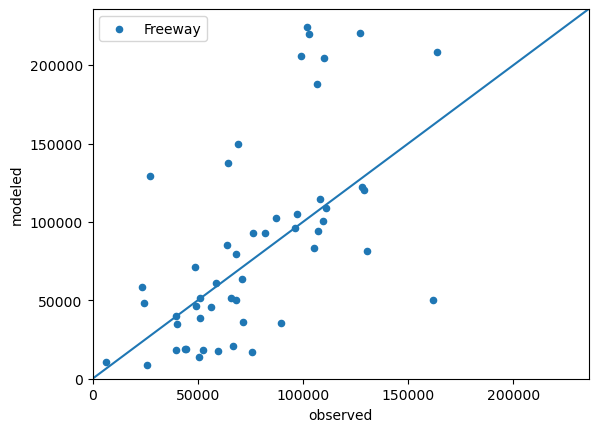

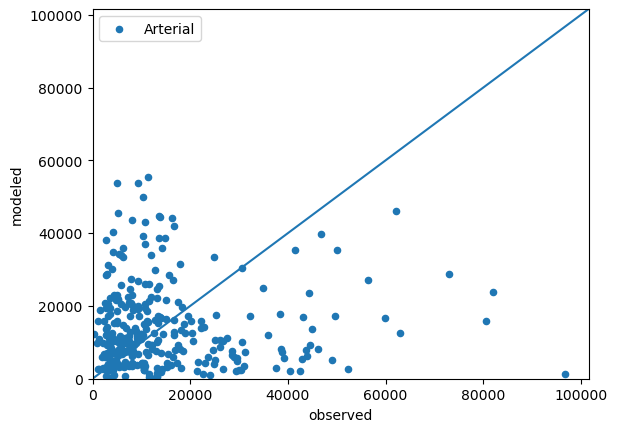

In [223]:
df1 = df[df['county'] == 'Pierce']
for factype in ['Freeway','Arterial']:
    _df = df1[df1['@facilitytype'] == factype]
    ax = _df.plot(kind='scatter', x='observed', y='modeled', label=factype)
    lim = _df[['observed','modeled']].max().max()*1.05
    ax.set_ylim(0,lim)
    ax.set_xlim(0,lim)
    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x)
    slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed'],_df['modeled'])
    print('r^2 ' + str(factype) + ': ' + str(r_value))

By Facility Type - Other Counties

r^2 Freeway: 0.2527522641235111
r^2 Arterial: 0.10390034360496476


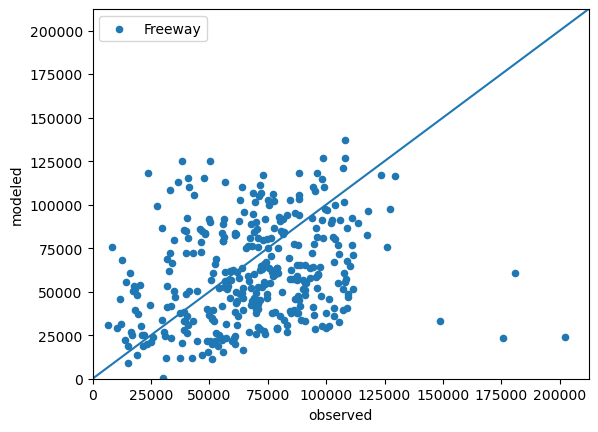

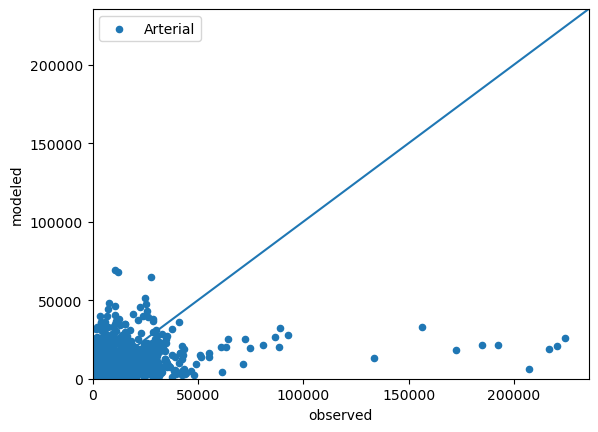

In [224]:
df2 = df[(df['county'] != 'Pierce') & (~df.county.isna())]
if df2.shape[0] > 0:
    for factype in ['Freeway','Arterial']:
        _df = df2[df2['@facilitytype'] == factype]
        ax = _df.plot(kind='scatter', x='observed', y='modeled', label=factype)
        lim = _df[['observed','modeled']].max().max()*1.05
        ax.set_ylim(0,lim)
        ax.set_xlim(0,lim)
        x = np.linspace(*ax.get_xlim())
        ax.plot(x, x)
        slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed'],_df['modeled'])
        print('r^2 ' + str(factype) + ': ' + str(r_value))

**Hourly Volumes**


r^2: 0.8951998926510769


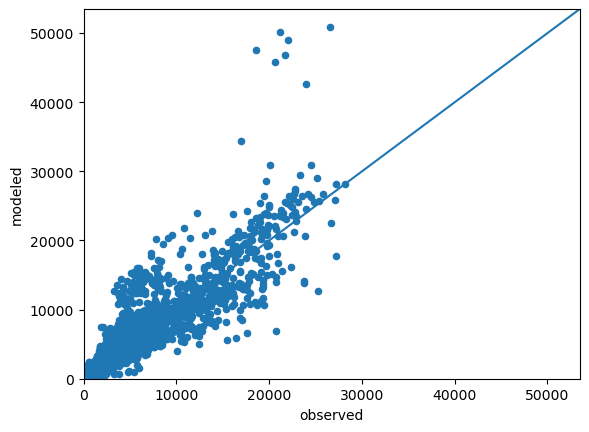

In [225]:
df = pd.read_csv(os.path.join(relative_path,'validation','hourly_volume.csv'))
ax = df.plot(kind='scatter', x='observed', y='modeled')
lim = df[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df['observed'],df['modeled'])
print('r^2: ' + str(r_value))

**Hourly Volumes - Pierce County**

r^2: 0.6870097574581774


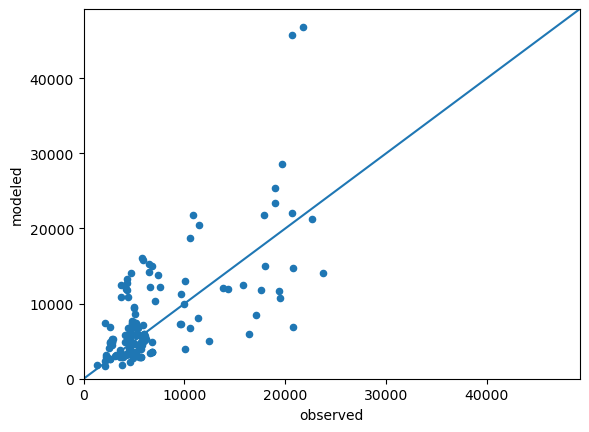

In [226]:
df1 = df[df['county'] == 'Pierce']
ax = df1.plot(kind='scatter', x='observed', y='modeled')
lim = df1[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df1['observed'],df1['modeled'])
print('r^2: ' + str(r_value))

**Hourly Volumes - Other Counties**

r^2: 0.9082543812366279


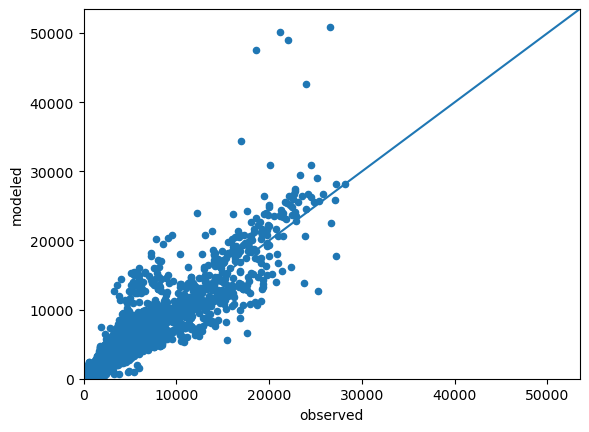

In [227]:
df2 = df[df['county'] != 'Pierce']
ax = df2.plot(kind='scatter', x='observed', y='modeled')
lim = df2[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df2['observed'],df2['modeled'])
print('r^2: ' + str(r_value))

# Screenlines

In [228]:
df = pd.read_csv(os.path.join(relative_path,'validation','screenlines.csv'))
df = pd.concat([df,df.sum(numeric_only=True).to_frame().T], ignore_index=True)
df.at[df.index[-1], 'name'] = 'TOTAL'
#df.at['C', 'name'] = 10
df['percent_diff'] = df['diff']/df['observed']
df[['percent_diff']] = df[['percent_diff']].applymap(format_percent)
df

,name,observed,modeled,county,diff,percent_diff
0,AUBURN - SOUTH KING,"592,476","550,592",King,"-41,884",-7.07%
1,KENT,"559,335","524,255",King,"-35,080",-6.27%
2,SHIP CANAL,"481,563","564,363",King,"82,800",17.19%
3,SEATTLE - SOUTH OF CBD,"473,322","521,265",King,"47,943",10.13%
4,MILL CREEK,"391,447","389,829",King,"-1,618",-0.41%
5,SOUTH BELLEVUE,"389,700","370,151",King,"-19,549",-5.02%
6,KIRKLAND-REDMOND,"380,783","441,477",King,"60,694",15.94%
7,SEATTLE - NORTH,"356,051","366,693",King,"10,642",2.99%
8,BOTHELL,"291,573","304,341",King,"12,768",4.38%
9,LYNNWOOD-BOTHELL,"260,099","306,719",King,"46,620",17.92%


r^2 : 0.9795452146444975


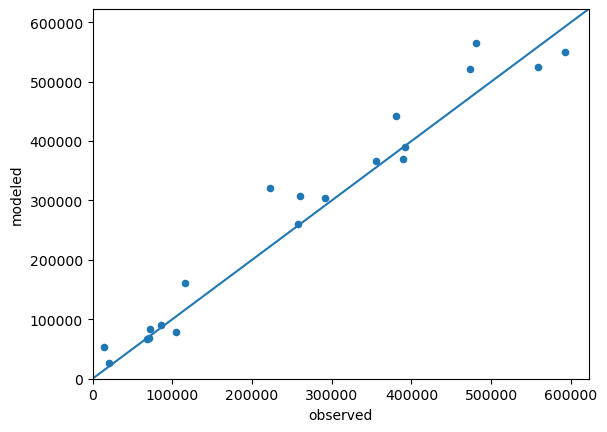

In [229]:
df = df.head(-1)
ax = df.plot(kind='scatter', x='observed', y='modeled')
lim = df[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df['observed'],df['modeled'])
print('r^2 : ' + str(r_value))

#### Screelines - Pierce County

In [230]:
df1 = df[df['county'] == 'Pierce']
df1 = pd.concat([df1,df1.sum(numeric_only=True).to_frame().T], ignore_index=True)
df1.at[df1.index[-1], 'name'] = 'TOTAL'
#df1.at['C', 'name'] = 10
df1['percent_diff'] = df1['diff']/df1['observed']
df1[['percent_diff']] = df1[['percent_diff']].applymap(format_percent)
df1

,name,observed,modeled,county,diff,percent_diff
0,TOTAL,0,0,NaN,0,nan%


In [231]:
# df1 = df1.head(-1)
# ax = df1.plot(kind='scatter', x='observed', y='modeled')
# lim = df[['observed','modeled']].max().max()*1.05
# ax.set_ylim(0,lim)
# ax.set_xlim(0,lim)
# x = np.linspace(*ax.get_xlim())
# ax.plot(x, x)
# slope, intercept, r_value, p_value, std_err = stats.linregress(df1['observed'],df1['modeled'])
# print('r^2 : ' + str(r_value))

#### Screelines - Other Counties

In [232]:
df2 = df[df['county'] != 'Pierce']
df2 = pd.concat([df2,df2.sum(numeric_only=True).to_frame().T], ignore_index=True)
df2.at[df2.index[-1], 'name'] = 'TOTAL'
#df2.at['C', 'name'] = 10
df2['percent_diff'] = df2['diff']/df2['observed']
df2[['percent_diff']] = df2[['percent_diff']].applymap(format_percent)
df2

,name,observed,modeled,county,diff,percent_diff
0,AUBURN - SOUTH KING,"592,476","550,592",King,"-41,884",-7.07%
1,KENT,"559,335","524,255",King,"-35,080",-6.27%
2,SHIP CANAL,"481,563","564,363",King,"82,800",17.19%
3,SEATTLE - SOUTH OF CBD,"473,322","521,265",King,"47,943",10.13%
4,MILL CREEK,"391,447","389,829",King,"-1,618",-0.41%
5,SOUTH BELLEVUE,"389,700","370,151",King,"-19,549",-5.02%
6,KIRKLAND-REDMOND,"380,783","441,477",King,"60,694",15.94%
7,SEATTLE - NORTH,"356,051","366,693",King,"10,642",2.99%
8,BOTHELL,"291,573","304,341",King,"12,768",4.38%
9,LYNNWOOD-BOTHELL,"260,099","306,719",King,"46,620",17.92%


r^2 : 0.9795452146444975


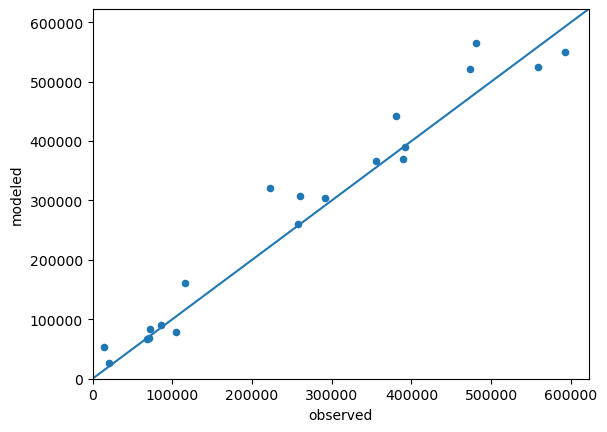

In [233]:
df2 = df2.head(-1)
if df2.shape[0] > 0:
    ax = df2.plot(kind='scatter', x='observed', y='modeled')
    lim = df[['observed','modeled']].max().max()*1.05
    ax.set_ylim(0,lim)
    ax.set_xlim(0,lim)
    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x)
    slope, intercept, r_value, p_value, std_err = stats.linregress(df2['observed'],df2['modeled'])
    print('r^2 : ' + str(r_value))

# Transit Boarding
----
### By Agency

In [234]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'daily_boardings_by_agency.csv')
df['diff'] = df['model_boardings'] - df['2023']
df[['model_boardings','2023', '2024','diff']] = df[['model_boardings','2023', '2024','diff']].astype('float')
sorted_values = df.sort_values('2023', ascending=False).agency.to_list() + ['TOTAL']
df = pd.concat([df,df.sum(numeric_only=True).to_frame().T], ignore_index=True)
df.at[df.index[-1], 'agency'] = 'TOTAL'
df['perc_diff'] = df['diff']/df['2023']
df['perc_diff'] = df[['perc_diff']].applymap(format_percent)
df.set_index('agency').reindex(sorted_values)

,model_boardings,2023,2024,diff,perc_diff
agency,,,,,
King County Metro,"316,723","226,197","240,817","90,526",40.02%
Sound Transit,"190,647","111,130","128,521","79,517",71.55%
Pierce Transit,"22,139","20,108","20,852","2,031",10.10%
Community Transit,"30,800","10,979","12,805","19,821",180.55%
Washington Ferries,"6,439","7,883","8,614","-1,444",-18.31%
Kitsap Transit,"8,651","4,822","5,816","3,829",79.40%
Everett Transit,"8,101","3,993","5,471","4,108",102.87%
TOTAL,"583,499","385,112","422,896","198,388",51.51%


### By Route for PierceTransit

In [235]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'daily_boardings_key_routes.csv')
df['diff'] = df['model_boardings'] - df['2023']
df[['model_boardings','2023', '2024','diff']] = df[['model_boardings','2023', '2024','diff']].astype('float')
df_piercetransit = df[df.agency=='Pierce Transit'].copy()
df_piercetransit = df_piercetransit.sort_values('2023', ascending=False)
df_piercetransit['route_code'] = df_piercetransit['route_code']-2000
df_piercetransit = pd.concat([df_piercetransit,df_piercetransit.sum(numeric_only=True).to_frame().T], ignore_index=True)
df_piercetransit.at[df_piercetransit.index[-1], 'agency'] = 'TOTAL'
df_piercetransit.at[df_piercetransit.index[-1], 'route_code'] = 0
df_piercetransit.at[df_piercetransit.index[-1], 'description'] = 'TOTAL'
df_piercetransit['perc_diff'] = (df_piercetransit['diff']/df_piercetransit['2023']).values
df_piercetransit['perc_diff'] = df_piercetransit[['perc_diff']].applymap(format_percent)
df_piercetransit

,description,route_code,agency,model_boardings,2023,2024,diff,perc_diff
0,TOTAL,0,TOTAL,0,0,0,0,nan%


----
### Key Routes
#### Ferries

In [236]:
# df = pd.read_csv(os.path.join(relative_path,'validation/') + 'daily_boardings_key_routes.csv', index_col='description')
# df[['observed_5to20','modeled_5to20']] = df[['observed_5to20','modeled_5to20']].astype('float')
# _df = df[df['route_code'].isin([5001,5002,5003,5004,5005,5006,5007,1973,1975])].reset_index()
# _df.drop(['route_code','agency'], axis=1, inplace=True)
# sorted_values = _df.sort_values('observed_5to20', ascending=False).description.to_list() + ['TOTAL']
# _df = _df.append(_df.sum(numeric_only=True), ignore_index=True)
# _df.at[_df.index[-1], 'description'] = 'TOTAL'
# _df[['perc_diff']] = _df['diff']/_df['observed_5to20']
# _df[['perc_diff']] = _df[['perc_diff']].applymap(format_percent)
# _df

In [237]:
# if len(_df) > 0:
#     ax = _df.plot(kind='scatter', x='observed_5to20', y='modeled_5to20')
#     lim = _df[['observed_5to20','modeled_5to20']].max().max()*1.05
#     ax.set_ylim(0,lim)
#     ax.set_xlim(0,lim)
#     x = np.linspace(*ax.get_xlim())
#     ax.plot(x, x)
#     slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed_5to20'],_df['modeled_5to20'])
#     print('r^2 ' + str('') + ': ' + str(r_value))

#### Bikes on Ferries

In [238]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'bike_ferry_boardings.csv')
df['route_code'] = df['route_code'].astype('int')
df[['route_code','description', '@bvol']].sort_values('@bvol', ascending=False)

,route_code,description,@bvol
1,4202,Brem-Annapolis FF,555
0,4201,Brem-Pt Orchard FF,398
3,5002,WSF Seattle-Bain Isl,61
6,5005,WSF Fauntleroy-Vashn,53
7,5007,WSF Pt Def-Tahlequah,46
5,5004,WSF Fauntleroy-Swrth,32
2,5001,WSF Edmonds-Kingston,16
4,5003,WSF Seattle-Brem,6


#### Rail

In [239]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'daily_boardings_key_routes.csv', index_col='description')
df

,route_code,agency,model_boardings,2023,2024
description,,,,,
A Line,1671,King County Metro,"9,661","8,178","9,415"
B Line,1672,King County Metro,"6,286","4,214","4,694"
C Line,1673,King County Metro,1,"7,224","7,541"
D Line,1674,King County Metro,"4,594","8,805","9,634"
Swift Blue,3701,Community Transit,"14,258","5,403","6,278"
Swift Green,3702,Community Transit,"3,542","2,017","2,748"
Light Rail Tacoma,6995,Sound Transit,"2,835","1,544","3,496"
Commutr Rail Tac-Sea,6998,Sound Transit,"14,860","6,038","7,168"
Commutr Rail Evt-Sea,6999,Sound Transit,3,316,367


In [240]:
# df = pd.read_csv(os.path.join(relative_path,'validation/') + 'daily_boardings_key_routes.csv', index_col='description')
# df[['model_boardings','2023','2024']] = df[['model_boardings','2023','2024']].astype('float')
# _df = df[df['route_code'].isin([6996,6999,6998])].reset_index()
# _df['description'] = _df['route_code'].map({6998: 'Sounder South', 6999: 'Sounder North',6996: 'Link Red Line'})
# _df.drop(['route_code','agency'], axis=1, inplace=True)
# _df[['perc_diff']] = _df[['perc_diff']].applymap(format_percent)

# _df

In [241]:
# if len(_df) > 0: 
#     ax = _df.plot(kind='scatter', x='observed_5to20', y='modeled_5to20')
#     lim = _df[['observed_5to20','modeled_5to20']].max().max()*1.05
#     ax.set_ylim(0,lim)
#     ax.set_xlim(0,lim)
#     x = np.linspace(*ax.get_xlim())
#     ax.plot(x, x)
#     slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed_5to20'],_df['modeled_5to20'])
#     print('r^2 ' + str('') + ': ' + str(r_value))

#### RapidRide, Busiest Buses, Streetcar

In [242]:
# _df = df[df['route_code'].isin([1671,1672,1673,1674,1675,1676,6550,1007,1040,1997,1998])].reset_index()
# _df['description'] = _df['route_code'].map({1671: 'A Line RapidRide', 1672: 'B Line RapidRide',
#                                             1673: 'C Line RapidRide', 1674: 'D Line RapidRide',
#                                             1675: 'E Line RapidRide', 1676: 'F Line RapidRide',
#                                             6550: 'Sound Transit 550', 1040: 'KC Metro 40', 1007: 'KC Metro 7',
#                                             1997: 'SLU Streetcar', 1998: 'First Hill Streetcar'})
# _df.drop(['route_code','agency'], axis=1, inplace=True)
# _df[['perc_diff']] = _df[['perc_diff']].applymap(format_percent)
# _df.sort_values('modeled_5to20', ascending=False)

In [243]:
# if len(_df) > 0: 
#     ax = _df.plot(kind='scatter', x='observed_5to20', y='modeled_5to20')
#     lim = _df[['observed_5to20','modeled_5to20']].max().max()*1.05
#     ax.set_ylim(0,lim)
#     ax.set_xlim(0,lim)
#     x = np.linspace(*ax.get_xlim())
#     ax.plot(x, x)
#     slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed_5to20'],_df['modeled_5to20'])
#     print('r^2 ' + str('') + ': ' + str(r_value))

---
### Lines by Agency

r^2 Community Transit: 0.9846386384730854
r^2 Everett Transit: 0.9869447452416499
r^2 King County Metro: 0.7955510542830639
r^2 Kitsap Transit: 0.6947030561258584
r^2 Pierce Transit: 0.6661394248775928
r^2 Sound Transit: 0.9919852064895639
r^2 Washington Ferries: 0.9882430357852672


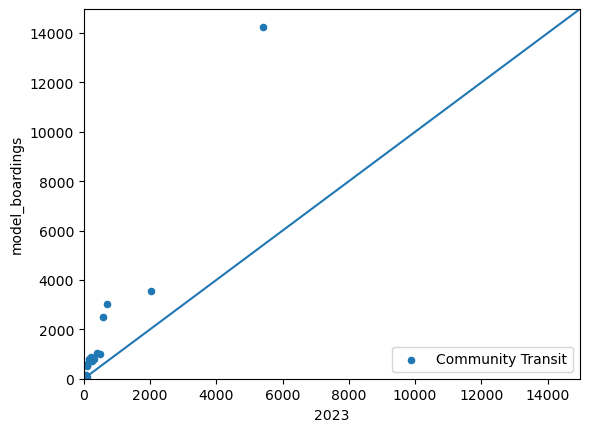

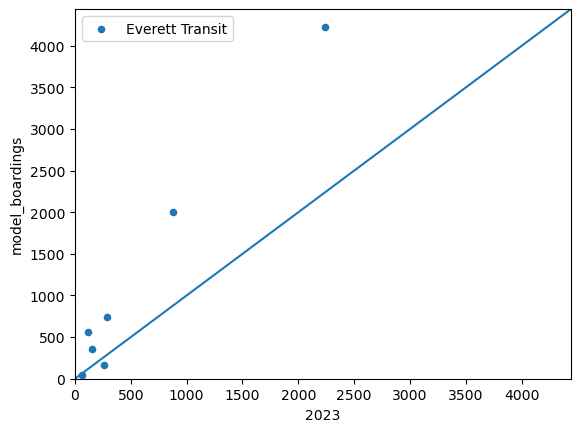

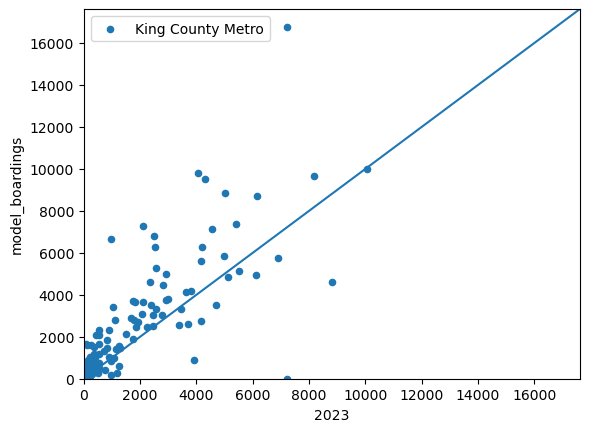

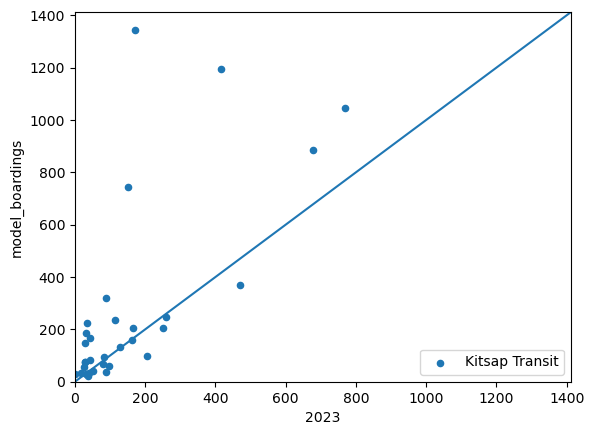

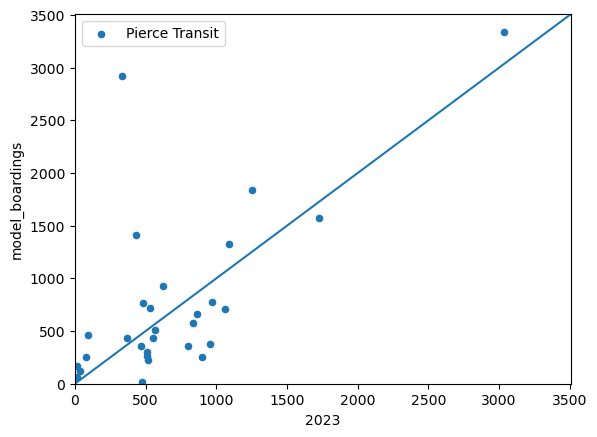

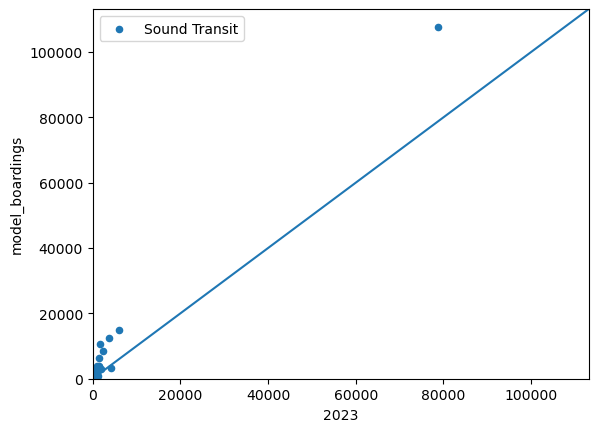

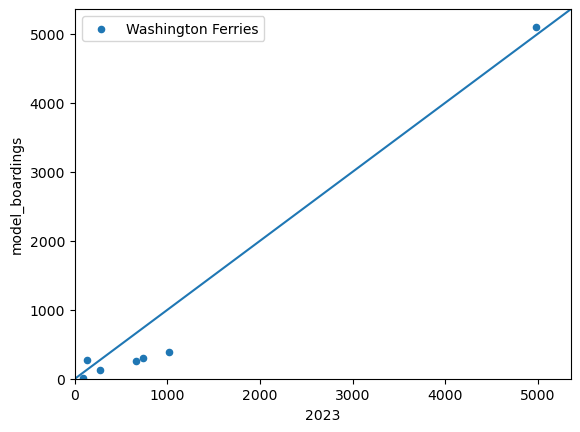

In [244]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'daily_boardings_by_line.csv', index_col='agency')
# df = df[-df['agency'].isnull()]

for agency in np.unique(df.index):
    _df = df.loc[agency,:]
    if (type(_df) == pd.core.frame.DataFrame) & (len(df) > 0):
        ax = _df.plot(kind='scatter', x='2023', y='model_boardings', label=agency)
        lim = _df[['2023','model_boardings']].max().max()*1.05
        ax.set_ylim(0,lim)
        ax.set_xlim(0,lim)
        x = np.linspace(*ax.get_xlim())
        ax.plot(x, x)
        slope, intercept, r_value, p_value, std_err = stats.linregress(_df['2023'],_df['model_boardings'])
        print('r^2 ' + str(agency) + ': ' + str(r_value))

# Light Rail Station Boardings
----
Red Line

In [245]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'light_rail_boardings.csv', index_col='station_name')
df['diff'] = df['model_boardings']-df['observed_boardings']
df['percent_diff'] = df['diff']/df['observed_boardings']
df[['percent_diff']] = df[['percent_diff']].applymap(format_percent)
df

,observed_boardings,model_boardings,diff,percent_diff
station_name,,,,
Husky Stadium,"6,134","4,149","-1,985",-32.36%
Westlake,"8,845","21,442","12,597",142.42%
Symphony,"4,324","9,372","5,048",116.75%
Pioneer Square,"2,400","7,529","5,129",213.70%
Int'l District,"4,399","3,051","-1,348",-30.63%
Capitol Hill,"7,667","9,027","1,360",17.74%
Stadium,"1,731",770,-961,-55.53%
SODO,"1,669","4,305","2,636",157.93%
Beacon Hill,"2,147","1,241",-906,-42.19%


Sound Transit Station Groupings

In [246]:
# df_combined = df.copy()

# df_combined['station_group'] = df.index
# df_combined.loc[['Westlake'],'station_group'] = 'Westlake/University St'
# df_combined.loc[['University St'],'station_group'] = 'Westlake/University St'

# df_combined.loc[['Pioneer Square'],'station_group'] = "Pioneer Square/Int'l District"
# df_combined.loc[["Int'l District"],'station_group'] = "Pioneer Square/Int'l District"

# df_combined.loc[['Stadium'],'station_group'] = 'Stadium/SODO'
# df_combined.loc[['SODO'],'station_group'] = 'Stadium/SODO'

# df_combined.loc[['Beacon Hill'],'station_group'] = 'Beacon Hill/Mount Baker'
# df_combined.loc[['Mount Baker'],'station_group'] = 'Beacon Hill/Mount Baker'

# df_combined.loc[['Othello'],'station_group'] = 'Othello/Rainier Beach'
# df_combined.loc[['Rainier Beach'],'station_group'] = 'Othello/Rainier Beach'

# df_combined = df_combined.groupby('station_group').sum()[['observed_boardings','model_boardings']]
# df_combined['diff'] = df_combined['model_boardings']-df_combined['observed_boardings']
# df_combined['percent_diff'] = df_combined['diff']/df_combined['observed_boardings']
# df_combined[['percent_diff']] = df_combined[['percent_diff']].applymap(format_percent)

# df_combined.loc[['Husky Stadium','Capitol Hill','Westlake/University St',"Pioneer Square/Int'l District",
#                  'Stadium/SODO','Beacon Hill/Mount Baker','Columbia City','Othello/Rainier Beach',
#                 "Tukwila Int'l Blvd",'SeaTac/Airport','Angle Lake']]

# Stop Transfers

### Light Rail

In [247]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'light_rail_transfers.csv', index_col='station_name')
pd.options.display.float_format = '{:0,.2f}'.format
df[['percent_diff']] = df[['percent_diff']].applymap(format_percent)
df

,modeled_transfer_rate,observed_transfer_rate,diff,percent_diff
station_name,,,,
Husky Stadium,0.78,-99.00,99.78,-100.79%
Westlake,0.10,0.36,-0.27,-73.19%
Symphony,0.07,0.20,-0.13,-65.14%
Pioneer Square,0.24,0.16,0.08,49.88%
Int'l District,0.50,0.45,0.05,10.11%
Capitol Hill,0.04,-99.00,99.04,-100.04%
Stadium,0.37,0.12,0.25,209.47%
SODO,0.54,0.31,0.23,72.86%
Beacon Hill,0.37,0.35,0.02,6.03%


# Externals

In [248]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'external_volumes.csv', index_col='location')
pd.options.display.float_format = '{:0,.0f}'.format
df = df.drop('diff', axis=1)
df['diff'] = df['modeled']-df['observed']
df = df.fillna(0)
df.loc['Total',['observed','modeled','diff']] = df[['observed','modeled','diff']].sum()
df['percent_diff'] = df['diff']/df['observed']
df[['percent_diff']] = df[['percent_diff']].applymap(format_percent)

df[['external_station']] = df[['external_station']].applymap('{:0.0f}'.format)
df.replace('nan', '', regex=True)

,external_station,county,observed,modeled,diff,percent_diff
location,,,,,,
I-5 to Olympia,3733,Pierce,"129,250","84,822","-44,428",-34.37%
I-5 to Mount Vernon,3744,Snohomish,"65,880","37,400","-28,480",-43.23%
I-90 @ Snoqualmie Pass,3739,King,"30,500","27,281","-3,219",-10.56%
SR-507 to Yelm,3734,Pierce,"22,700","6,750","-15,950",-70.27%
SR-532 to Camano Island,3746,Snohomish,"21,250","5,053","-16,197",-76.22%
SR-3 to Belfair,3749,Kitsap,"20,329","9,645","-10,684",-52.55%
Hood Canal Bridge,3748,Kitsap,"18,200","6,187","-12,013",-66.01%
Mukilteo-Clinton Ferry,3747,Snohomish,"9,800","4,355","-5,445",-55.56%
SR-530 N/O Stanwood,3745,Snohomish,"9,100",89,"-9,011",-99.02%


#### Externals - Pierce County

In [249]:
df1 = df[df['county'] == 'Pierce']
pd.options.display.float_format = '{:0,.0f}'.format
df1 = df1.drop('diff', axis=1)
df1['diff'] = df1['modeled']-df1['observed']
df1 = df1.fillna(0)
df1.loc['Total',['observed','modeled','diff']] = df1[['observed','modeled','diff']].sum()
df1['percent_diff'] = df1['diff']/df1['observed']
df1[['percent_diff']] = df1[['percent_diff']].applymap(format_percent)

#df1[['external_station']] = df1[['external_station']].applymap('{:0.0f}'.format)
df1.replace('nan', '', regex=True)

,external_station,county,observed,modeled,percent_diff,diff
location,,,,,,
I-5 to Olympia,3733,Pierce,"129,250","84,822",-34.37%,"-44,428"
SR-507 to Yelm,3734,Pierce,"22,700","6,750",-70.27%,"-15,950"
SR-302 to Shelton,3750,Pierce,"4,550","4,546",-0.10%,-4
SR-7 to Morton,3735,Pierce,"2,900",746,-74.29%,"-2,154"
SR-706 to Longmire,3736,Pierce,"1,800",55,-96.93%,"-1,745"
SR 410 E/O Cayuse Pass,3738,Pierce,"1,200",139,-88.40%,"-1,061"
SR-123 S/O Cayuse Pass,3737,Pierce,920,59,-93.58%,-861
Total,NaN,NaN,"163,320","97,117",-40.54%,"-66,203"


#### Externals - Other Counties

In [250]:
df2 = df[df['county'].isin(['Snohomish', 'Kitsap', 'King'])]
pd.options.display.float_format = '{:0,.0f}'.format
df2 = df2.drop('diff', axis=1)
df2['diff'] = df2['modeled']-df2['observed']
df2 = df2.fillna(0)
df2.loc['Total',['observed','modeled','diff']] = df2[['observed','modeled','diff']].sum()
df2['percent_diff'] = df2['diff']/df2['observed']
df2[['percent_diff']] = df2[['percent_diff']].applymap(format_percent)

#df2[['external_station']] = df2[['external_station']].applymap('{:0.0f}'.format)
df2.replace('nan', '', regex=True)

,external_station,county,observed,modeled,percent_diff,diff
location,,,,,,
I-5 to Mount Vernon,3744,Snohomish,"65,880","37,400",-43.23%,"-28,480"
I-90 @ Snoqualmie Pass,3739,King,"30,500","27,281",-10.56%,"-3,219"
SR-532 to Camano Island,3746,Snohomish,"21,250","5,053",-76.22%,"-16,197"
SR-3 to Belfair,3749,Kitsap,"20,329","9,645",-52.55%,"-10,684"
Hood Canal Bridge,3748,Kitsap,"18,200","6,187",-66.01%,"-12,013"
Mukilteo-Clinton Ferry,3747,Snohomish,"9,800","4,355",-55.56%,"-5,445"
SR-530 N/O Stanwood,3745,Snohomish,"9,100",89,-99.02%,"-9,011"
SR-2 @ Stevens Pass,3740,King,"3,050","3,648",19.61%,598
SR-530 N/O Darrington,3742,Snohomish,"2,100",193,-90.83%,"-1,907"


# Corridor Speed

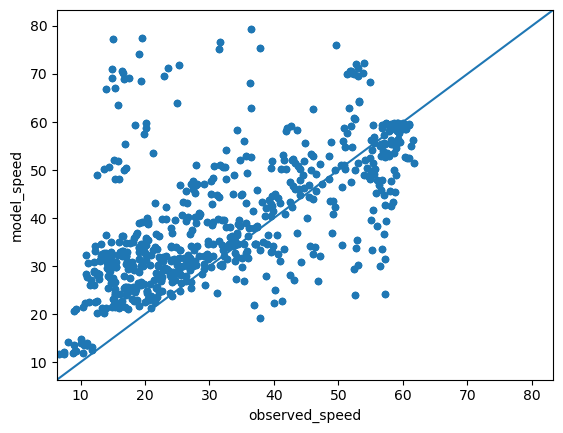

In [251]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'corridor_speeds.csv')
ax = df.plot(kind='scatter', y='model_speed', x='observed_speed')
maxlim = df[['observed_speed','model_speed']].max().max()*1.05
minlim = df[['observed_speed','model_speed']].min().min()*0.95
ax.set_ylim(minlim,maxlim)
ax.set_xlim(minlim,maxlim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)

## Pierce County

In [252]:
# ax = df.loc[df.county=='Pierce'].plot(kind='scatter', y='model_speed', x='observed_speed')
# maxlim = df.loc[df.county=='Pierce'][['observed_speed','model_speed']].max().max()*1.05
# minlim = df.loc[df.county=='Pierce'][['observed_speed','model_speed']].min().min()*0.95
# ax.set_ylim(minlim,maxlim)
# ax.set_xlim(minlim,maxlim)
# x = np.linspace(*ax.get_xlim())
# ax.plot(x, x)

## Other Counties

In [253]:
# _df = df.loc[df.county!='Pierce']
# _df = _df.groupby(['Corridor_Number', 'tod'], as_index=False).agg({'auto_time':sum, 'length':sum,'observed_speed':np.mean}).\
# assign(model_speed=lambda xdf: xdf.length*60/xdf.auto_time)
# ax = _df.plot(kind='scatter', y='model_speed', x='observed_speed')
# maxlim = _df[['observed_speed','model_speed']].max().max()*1.05
# minlim = _df[['observed_speed','model_speed']].min().min()*0.95
# ax.set_ylim(minlim,maxlim)
# ax.set_xlim(minlim,maxlim)
# x = np.linspace(*ax.get_xlim())
# ax.plot(x, x)

### AM Peak, Primary Corridors

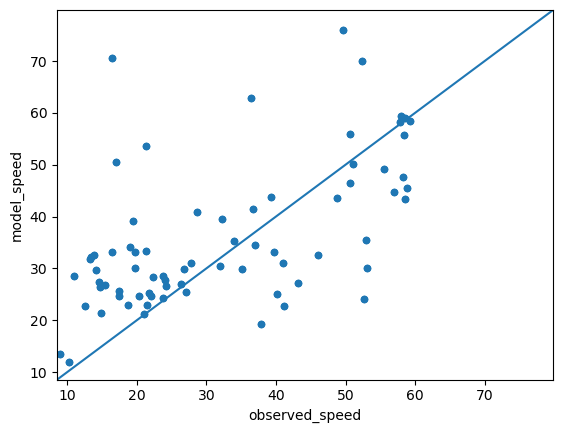

In [254]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'corridor_speeds.csv')
ax = df[df['tod'] == '7to8'].plot(kind='scatter', x='observed_speed', y='model_speed')
maxlim = df[df['tod'] == '7to8'][['observed_speed','model_speed']].max().max()*1.05
minlim = df[df['tod'] == '7to8'][['observed_speed','model_speed']].min().min()*0.95
ax.set_ylim(minlim,maxlim)
ax.set_xlim(minlim,maxlim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)

In [255]:
# Show daily AM and PM peaks by corridor
df[df['tod'] == '7to8'].assign(diff=lambda _df: np.abs(_df.model_speed-_df.observed_speed)).sort_values('diff', ascending=False)[['Corridor_Description','model_speed','observed_speed']].head(20)

,Corridor_Description,model_speed,observed_speed
1018,"56th Street/Cirque, Bridgeport to Alaska - EB",71,16
367,"56th Street/Cirque, Bridgeport to Alaska - EB",71,16
358,"56th Street/Cirque, Alaska to Bridgeport - WB",50,17
1009,"56th Street/Cirque, Alaska to Bridgeport - WB",50,17
982,"15th Ave/Elliott, Western Ave to NW 80th St - NB",54,21
331,"15th Ave/Elliott, Western Ave to NW 80th St - NB",54,21
150,Seattle to Bellevue via 520 - WB,24,53
801,Seattle to Bellevue via 520 - WB,24,53
323,"SR 9, SR 522 to SR 531 - NB",63,36
974,"SR 9, SR 522 to SR 531 - NB",63,36


## Pierce County

In [256]:
# df = pd.read_csv(os.path.join(relative_path,'validation/') + 'corridor_speeds_county.csv')
# df = df.loc[df.county=='Pierce']
# ax = df[df['tod'] == '7to8'].plot(kind='scatter', x='observed_speed', y='model_speed')
# maxlim = df[df['tod'] == '7to8'][['observed_speed','model_speed']].max().max()*1.05
# minlim = df[df['tod'] == '7to8'][['observed_speed','model_speed']].min().min()*0.95
# ax.set_ylim(minlim,maxlim)
# ax.set_xlim(minlim,maxlim)
# x = np.linspace(*ax.get_xlim())
# ax.plot(x, x)

In [257]:
# Show daily AM and PM peaks by corridor
# df[df['tod'] == '7to8'].assign(diff=lambda _df: np.abs(_df.model_speed-_df.observed_speed)).sort_values('diff', ascending=False)[['Corridor_Description','model_speed','observed_speed']].head(20)

## Other Counties

In [258]:
# df = pd.read_csv(os.path.join(relative_path,'validation/') + 'corridor_speeds_county.csv')
# df = df.loc[df.county!='Pierce']
# df = df.groupby(['Corridor_Number', 'Corridor_Description', 'tod'], as_index=False).agg({'auto_time':sum, 'length':sum,'observed_speed':np.mean}).\
# assign(model_speed=lambda df: df.length*60/df.auto_time)
# ax = df[df['tod'] == '7to8'].plot(kind='scatter', x='observed_speed', y='model_speed')
# maxlim = df[df['tod'] == '7to8'][['observed_speed','model_speed']].max().max()*1.05
# minlim = df[df['tod'] == '7to8'][['observed_speed','model_speed']].min().min()*0.95
# ax.set_ylim(minlim,maxlim)
# ax.set_xlim(minlim,maxlim)
# x = np.linspace(*ax.get_xlim())
# ax.plot(x, x)

In [259]:
# # Show daily AM and PM peaks by corridor
# df[df['tod'] == '7to8'].assign(diff=lambda _df: np.abs(_df.model_speed-_df.observed_speed)).sort_values('diff', ascending=False)[['Corridor_Description','model_speed','observed_speed']].head(20)

### PM Peak, Primary Corridors

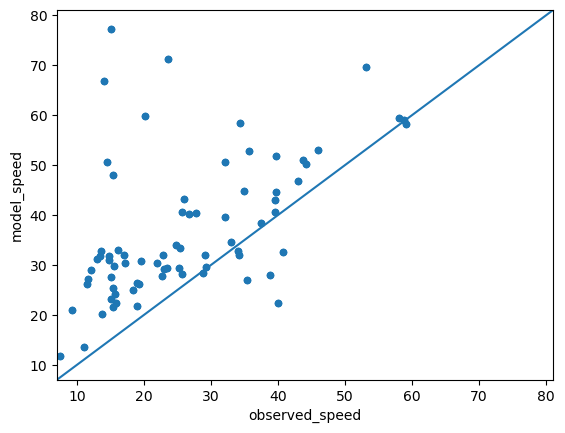

In [260]:
df = pd.read_csv(os.path.join(relative_path,'validation/') + 'corridor_speeds.csv')
ax = df[df['tod'] == '16to17'].plot(kind='scatter', x='observed_speed', y='model_speed')
maxlim = df[df['tod'] == '16to17'][['observed_speed','model_speed']].max().max()*1.05
minlim = df[df['tod'] == '16to17'][['observed_speed','model_speed']].min().min()*0.95
ax.set_ylim(minlim,maxlim)
ax.set_xlim(minlim,maxlim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)

In [261]:
df[df['tod'] == '16to17'].assign(diff=lambda _df: np.abs(_df.model_speed-_df.observed_speed)).sort_values('diff', ascending=False)[['Corridor_Description','model_speed','observed_speed']].head(20)

,Corridor_Description,model_speed,observed_speed
1066,"196th Street, Poplar Way to Olympic View Dr - WB",77,15
415,"196th Street, Poplar Way to Olympic View Dr - WB",77,15
362,"56th Street/Cirque, Bridgeport to Alaska - EB",67,14
1013,"56th Street/Cirque, Bridgeport to Alaska - EB",67,14
912,"SR 522, I-405 to SR 2 - EB",71,24
261,"SR 522, I-405 to SR 2 - EB",71,24
319,"SR 9, SR 522 to SR 531 - NB",60,20
970,"SR 9, SR 522 to SR 531 - NB",60,20
978,"15th Ave/Elliott, Western Ave to NW 80th St - NB",51,14
327,"15th Ave/Elliott, Western Ave to NW 80th St - NB",51,14


## Pierce County

In [262]:
# df = pd.read_csv(os.path.join(relative_path,'validation/') + 'corridor_speeds_county.csv')
# df = df.loc[df.county=='Pierce']
# ax = df[df['tod'] == '16to17'].plot(kind='scatter', x='observed_speed', y='model_speed')
# maxlim = df[df['tod'] == '16to17'][['observed_speed','model_speed']].max().max()*1.05
# minlim = df[df['tod'] == '16to17'][['observed_speed','model_speed']].min().min()*0.95
# ax.set_ylim(minlim,maxlim)
# ax.set_xlim(minlim,maxlim)
# x = np.linspace(*ax.get_xlim())
# ax.plot(x, x)

In [263]:
# Show daily AM and PM peaks by corridor
# df[df['tod'] == '16to17'].assign(diff=lambda _df: np.abs(_df.model_speed-_df.observed_speed)).sort_values('diff', ascending=False)[['Corridor_Description','model_speed','observed_speed']].head(20)

## Other Counties

In [264]:
# df = pd.read_csv(os.path.join(relative_path,'validation/') + 'corridor_speeds_county.csv')
# df = df.loc[df.county!='Pierce']
# df = df.groupby(['Corridor_Number', 'Corridor_Description', 'tod'], as_index=False).agg({'auto_time':sum, 'length':sum,'observed_speed':np.mean}).\
# assign(model_speed=lambda df: df.length*60/df.auto_time)
# ax = df[df['tod'] == '16to17'].plot(kind='scatter', x='observed_speed', y='model_speed')
# maxlim = df[df['tod'] == '16to17'][['observed_speed','model_speed']].max().max()*1.05
# minlim = df[df['tod'] == '16to17'][['observed_speed','model_speed']].min().min()*0.95
# ax.set_ylim(minlim,maxlim)
# ax.set_xlim(minlim,maxlim)
# x = np.linspace(*ax.get_xlim())
# ax.plot(x, x)

In [265]:
# Show daily AM and PM peaks by corridor
# df[df['tod'] == '16to17'].assign(diff=lambda _df: np.abs(_df.model_speed-_df.observed_speed)).sort_values('diff', ascending=False)[['Corridor_Description','model_speed','observed_speed']].head(20)